In [1]:
import os
import sys
import copy
import joblib

sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import torch

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import property_driven_ml.logics as logics
import property_driven_ml.training as training

from logic_test import (
    DoSHttpFloodPostcondition,
    TabularRuleConstraint,
    PortscanPostcondition,
    GlobalBounds
)
from sklearn.model_selection import train_test_split
from utils.preprocessing import (
    MODEL_CATEGORICAL_FEATURES,
    MODEL_NUMERIC_FEATURES,
    ENGINEERED_FEATURES,
    filter_labels,
)
from specs import ATTACK_SPECS
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
df_cicids2017_train = pd.read_csv("../data/cicids2017_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
df_cicids2017_test = pd.read_csv("../data/cicids2017_test.tsv", on_bad_lines="skip", delimiter="\t")
df_ciciot2023_train = pd.read_csv("../data/ciciot2023_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
df_ciciot2023_test = pd.read_csv("../data/ciciot2023_test.tsv", on_bad_lines="skip", delimiter="\t")

C:\Users\Rasmus\AppData\Local\Temp\ipykernel_6324\2615196177.py:3: DtypeWarning: Columns (0: duration, 1: orig_bytes, 2: resp_bytes) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ciciot2023_train = pd.read_csv("../data/ciciot2023_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")


In [3]:
TARGET_LABELS = [
    "BENIGN",
    "DOS_HTTP_FLOOD",
    "PORTSCAN",
]

In [4]:
PROPERTY_MODEL_FEATURES = (
    MODEL_CATEGORICAL_FEATURES
    + MODEL_NUMERIC_FEATURES
    + ENGINEERED_FEATURES
)

In [5]:
def compute_time_elapsed(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.sort_values(["id.orig_h", "id.resp_h", "ts"]).reset_index(drop=True)

    df["time_elapsed"] = (
        df.groupby(["id.orig_h", "id.resp_h"])["ts"]
        .diff()
        .fillna(999999.0)
    )

    return df

def compute_valid_tcp_handshake(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    proto_ok =  df["proto"].eq("tcp")
    history_ok = df["history"].str.contains(r"S.*h.*A", regex=True, na=False)

    df["valid_tcp_handshake"] = (proto_ok & history_ok).astype(int)
    return df

def compute_valid_http_conn(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    proto_ok =  df["proto"].eq("tcp")
    port_http = df["id.resp_p"].isin([80, 8080, 8000])
    port_https = df["id.resp_p"].isin([443, 8443])
    service_http = df["service"].str.lower().eq("http")
    service_https = df["service"].str.lower().eq("https")
    service_ssl = df["service"].str.lower().eq("ssl")
    has_data = df["history"].str.contains(r"D", regex=True, na=False)

    df["valid_http_conn"] = (
        proto_ok &
        ((port_http & service_http) | (port_https & (service_https | service_ssl))) 
        & has_data
    ).astype(int)
    return df

In [ ]:
def add_engineered_features(
    df: pd.DataFrame,
    window_seconds: float = 5.0,
) -> pd.DataFrame:
    df = df.copy()

    for col in MODEL_NUMERIC_FEATURES:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    existing_numeric = [c for c in MODEL_NUMERIC_FEATURES if c in df.columns]
    if existing_numeric:
        df[existing_numeric] = df[existing_numeric].replace([np.inf, -np.inf], np.nan)
        df[existing_numeric] = df[existing_numeric].fillna(0.0)

    df = add_engineered_features(df)
    df = compute_valid_tcp_handshake(df)
    df = compute_valid_http_conn(df)

    duration_safe = df["duration"].copy()
    duration_safe = duration_safe.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    duration_safe = duration_safe.mask(duration_safe <= 0, 1e-6)

    df["orig_pkt_rate"] = df["orig_pkts"] / duration_safe
    df["orig_byte_rate"] = df["orig_bytes"] / duration_safe

    # Portscan / attack-window features
    df["window_id"] = (df["ts"] // window_seconds).astype(int)
    group_cols = ["id.orig_h", "window_id"]

    FAILED_STATES = {"S0", "REJ", "RSTO", "RSTR", "RSTOS0", "RSTRH", "SH", "SHR"}
    df["is_failed_conn"] = df["conn_state"].astype(str).isin(FAILED_STATES).astype(int)

    agg = (
        df.groupby(group_cols)
        .agg(
            uniq_dst_ports=("id.resp_p", "nunique"),
            total_orig_pkts=("orig_pkts", "sum"),
            scan_duration=("duration", "max"),
            total_flows=("id.orig_h", "size"),
            failed_flows=("is_failed_conn", "sum"),
        )
        .reset_index()
    )

    agg["failed_flows"] = agg["failed_flows"].fillna(0.0)

    uniq_dst_ports_safe = agg["uniq_dst_ports"].replace(0, np.nan)
    total_flows_safe = agg["total_flows"].replace(0, np.nan)

    agg["pkts_per_port"] = (
        agg["total_orig_pkts"] / uniq_dst_ports_safe
    ).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    agg["fail_ratio"] = (
        agg["failed_flows"] / total_flows_safe
    ).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    df = df.merge(
        agg[
            [
                "id.orig_h",
                "window_id",
                "uniq_dst_ports",
                "pkts_per_port",
                "scan_duration",
                "fail_ratio",
            ]
        ],
        on=["id.orig_h", "window_id"],
        how="left",
    )

    for col in [
        *ENGINEERED_FEATURES,
        "uniq_dst_ports",
        "pkts_per_port",
        "scan_duration",
        "fail_ratio",
    ]:
        if col in df.columns:
            df[col] = (
                pd.to_numeric(df[col], errors="coerce")
                .replace([np.inf, -np.inf], np.nan)
                .fillna(0.0)
            )

    return df

: 

In [ ]:
feature_cols = PROPERTY_MODEL_FEATURES + ["id.resp_p"]
print("Using features:", feature_cols)

idx = {name: i for i, name in enumerate(feature_cols)}

label_to_idx = {label: i for i, label in enumerate(TARGET_LABELS)}

train_df = df_cicids2017_train.copy()
train_df = add_engineered_features(train_df)
train_df = train_df[train_df["label"].isin(TARGET_LABELS)].copy()

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"],
)

train_df["label_id"] = train_df["label"].map(label_to_idx)
val_df["label_id"] = val_df["label"].map(label_to_idx)


def make_loader(df, batch_size=1024, shuffle=False):
    X = torch.tensor(df[feature_cols].to_numpy(), dtype=torch.float32)
    y = torch.tensor(df["label_id"].to_numpy(), dtype=torch.long)
    return DataLoader(TensorDataset(X, y), batch_size=batch_size, shuffle=shuffle)


train_loader = make_loader(train_df, shuffle=True)
val_loader = make_loader(val_df, shuffle=False)

logic = logics.GoedelFuzzyLogic()
bool_logic = logics.BooleanLogic()
x_train_tensor = torch.tensor(
    train_df[feature_cols].to_numpy(),
    dtype=torch.float32,
)

lower_bound = x_train_tensor.min(dim=0).values.to(device)
upper_bound = x_train_tensor.max(dim=0).values.to(device)

model = nn.Sequential(
    nn.Linear(len(feature_cols), 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, len(label_to_idx)),
).to(device)

dos_constraint = TabularRuleConstraint(
    device,
    precondition=GlobalBounds(
        device=device
    ),
    postcondition=DoSHttpFloodPostcondition(
        idx=idx,
        class_idx=label_to_idx["DOS_HTTP_FLOOD"],
        dos_http_flood_specs = ATTACK_SPECS["dos_http_flood"],
        min_prob=0.80,

    ),
    lower_bound=lower_bound,
    upper_bound=upper_bound,
)

scan_constraint = TabularRuleConstraint(
    device,
    precondition=GlobalBounds(
        device=device
    ),
    postcondition=PortscanPostcondition(
        idx=idx,
        class_idx=label_to_idx["PORTSCAN"],
        min_prob=0.80,
        portscan_specs=ATTACK_SPECS["portscan"]
    ),
    lower_bound=lower_bound,
    upper_bound=upper_bound,
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
ce_fn = nn.CrossEntropyLoss()
# Set up adversarial oracle for constraint evaluation
oracle = training.PGD(logic, device, steps=10, restarts=1, step_size=0.01)

lambda_dos = 0.5
lambda_scan = 0.5
num_epochs = 3

for epoch in range(1, num_epochs + 1):
    model.train()
    dos_losses = []
    scan_losses = []
    dos_sats = []
    scan_sats = []

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        ce_loss = ce_fn(logits, y)

        x_adv_dos = oracle.attack(model, x, None, dos_constraint)
        dos_loss_train, dos_sat_train = dos_constraint.eval(
            model,
            x,
            x_adv_dos,
            None,
            logic,
            reduction="mean",
        )

        x_adv_scan = oracle.attack(model, x, None, scan_constraint)
        scan_loss_train, scan_sat_train = scan_constraint.eval(
            model,
            x,
            x_adv_scan,
            None,
            logic,
            reduction="mean",
        )

        dos_losses.append(dos_loss_train.item())
        scan_losses.append(scan_loss_train.item())
        dos_sats.append(dos_sat_train.item())
        scan_sats.append(scan_sat_train.item())
        loss = ce_loss + lambda_dos * dos_loss_train + lambda_scan * scan_loss_train

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(
        f"epoch={epoch} "
        f"ce_loss={ce_loss.item():.4f} "
        f"dos_loss_avg={sum(dos_losses) / len(dos_losses):.4f} "
        f"scan_loss_avg={sum(scan_losses) / len(scan_losses):.4f} "
        f"dos_sat_avg={sum(dos_sats) / len(dos_sats):.4f} "
        f"scan_sat_avg={sum(scan_sats) / len(scan_sats):.4f}"
    )
    model.eval()
    acc = 0.0
    dos_sat = 0.0
    scan_sat = 0.0
    n = 0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            acc += (logits.argmax(dim=1) == y).float().sum().item()

            # x_adv_dos = oracle.attack(model, x, None, dos_constraint)
            _, dos_sat_batch = dos_constraint.eval(
                model,
                x,
                None,
                None,
                bool_logic,
                reduction="sum",
            )

            # x_adv_scan = oracle.attack(model, x, None, scan_constraint)
            _, scan_sat_batch = scan_constraint.eval(
                model,
                x,
                None,
                None,
                bool_logic,
                reduction="sum",
            )

            dos_sat += dos_sat_batch.item()
            scan_sat += scan_sat_batch.item()
            n += x.size(0)

    print(
        f"epoch={epoch} "
        f"acc={acc / n:.4f} "
        f"dos_sat={dos_sat / n:.4f} "
        f"scan_sat={scan_sat / n:.4f}"
    )


Using features: ['proto', 'service', 'conn_state', 'history', 'duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'orig_pkt_rate', 'orig_byte_rate', 'time_elapsed', 'uniq_dst_ports', 'pkts_per_port', 'scan_duration', 'fail_ratio', 'valid_tcp_handshake', 'valid_http_conn', 'id.resp_p']


In [ ]:
def save_property_model(
    model,
    save_path,
    features,
    model_type
):
    joblib.dump(
        {
            "model": model.cpu(),
            "features": features,
            "model_type": model_type
        },
        save_path,
    )

    print(f"Saved model to: {save_path}")

In [ ]:
save_property_model(
    model,
    "models/property_model.joblib",
    features=feature_cols,
    model_type="mlp",
)

Saved model to: models/property_model.joblib


In [ ]:
def prepare_eval_df(df, target_labels, label_to_idx):
    df = df.copy()
    df = add_engineered_features(df)
    df = df[df["label"].isin(target_labels)].copy()
    df["label_id"] = df["label"].map(label_to_idx)
    return df

df_ciciot2023_train_eval = prepare_eval_df(df_ciciot2023_train, TARGET_LABELS, label_to_idx)

In [ ]:
def evaluate_model_metrics(
    model,
    df,
    label_to_idx,
    batch_size=256,
):
    loader = make_loader(df, batch_size=batch_size, shuffle=False)

    idx_to_label = {v: k for k, v in label_to_idx.items()}
    label_ids = list(range(len(idx_to_label)))
    labels = [idx_to_label[i] for i in label_ids]

    y_true, y_pred = [], []
    dos_loss_total = 0.0
    scan_loss_total = 0.0
    dos_sat_total = 0.0
    scan_sat_total = 0.0
    n = 0

    model = model.to(device)
    model.eval()
    print("device:", device)
    print("model device:", next(model.parameters()).device)

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            preds = logits.argmax(dim=1)

            dos_loss, dos_sat = dos_constraint.eval(
                model, x, None, None, bool_logic, reduction="sum"
            )

            scan_loss, scan_sat = scan_constraint.eval(
                model, x, None, None, bool_logic, reduction="sum"
            )

            batch_size_i = x.size(0)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

            dos_loss_total += dos_loss.item()
            scan_loss_total += scan_loss.item()
            dos_sat_total += dos_sat.item()
            scan_sat_total += scan_sat.item()
            n += batch_size_i

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    report = classification_report(
        y_true,
        y_pred,
        labels=label_ids,
        target_names=labels,
        digits=4,
        zero_division=0,
        output_dict=True,
    )

    for label_id, label_name in zip(label_ids, labels):
        mask = y_true == label_id
        report[label_name]["accuracy"] = (
            float((y_pred[mask] == label_id).mean()) if mask.sum() > 0 else 0.0
        )

    report_df = pd.DataFrame(report).T

    metrics = {
        "dos_loss": dos_loss_total / max(n, 1),
        "scan_loss": scan_loss_total / max(n, 1),
        "dos_sat": dos_sat_total / max(n, 1),
        "scan_sat": scan_sat_total / max(n, 1),
        "acc": float((y_true == y_pred).mean()),
    }

    cm = confusion_matrix(y_true, y_pred, labels=label_ids)

    return metrics, report_df, cm, labels

In [ ]:
def plot_eval_summary(metrics, report_df, cm, labels, model_name):
    fig, (ax1, ax2, ax3) = plt.subplots(
        3,
        1,
        figsize=(11, 15),
        gridspec_kw={"height_ratios": [3, 1.2, 2.8]},
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax1,
    )
    ax1.set_xlabel("Predicted")
    ax1.set_ylabel("Actual")
    ax1.set_title(f"{model_name} Confusion Matrix")

    ax2.axis("off")
    metrics_text = "\n".join(
        [
            f"accuracy: {metrics['acc']:.3f}",
            f"dos_loss: {metrics['dos_loss']:.3f}",
            f"scan_loss: {metrics['scan_loss']:.3f}",
            f"dos_sat: {metrics['dos_sat']:.3f}",
            f"scan_sat: {metrics['scan_sat']:.3f}",
        ]
    )
    ax2.text(
        0.01,
        0.95,
        metrics_text,
        va="top",
        ha="left",
        family="monospace",
        fontsize=11,
    )

    ax3.axis("off")
    ax3.text(
        0.01,
        0.95,
        report_df.round(3).to_string(),
        va="top",
        ha="left",
        family="monospace",
        fontsize=9,
    )
    ax3.set_title("Classification Report + Per-Label Accuracy")

    plt.tight_layout()
    plt.show()

In [ ]:
print("device:", device)
print("x device:", x.device)
print("model device:", next(model.parameters()).device)

device: cuda
x device: cuda:0
model device: cuda:0


In [ ]:
metrics, report_df, cm, labels = evaluate_model_metrics(
    model,
    df_ciciot2023_train_eval,
    label_to_idx,
)

device: cuda
model device: cuda:0


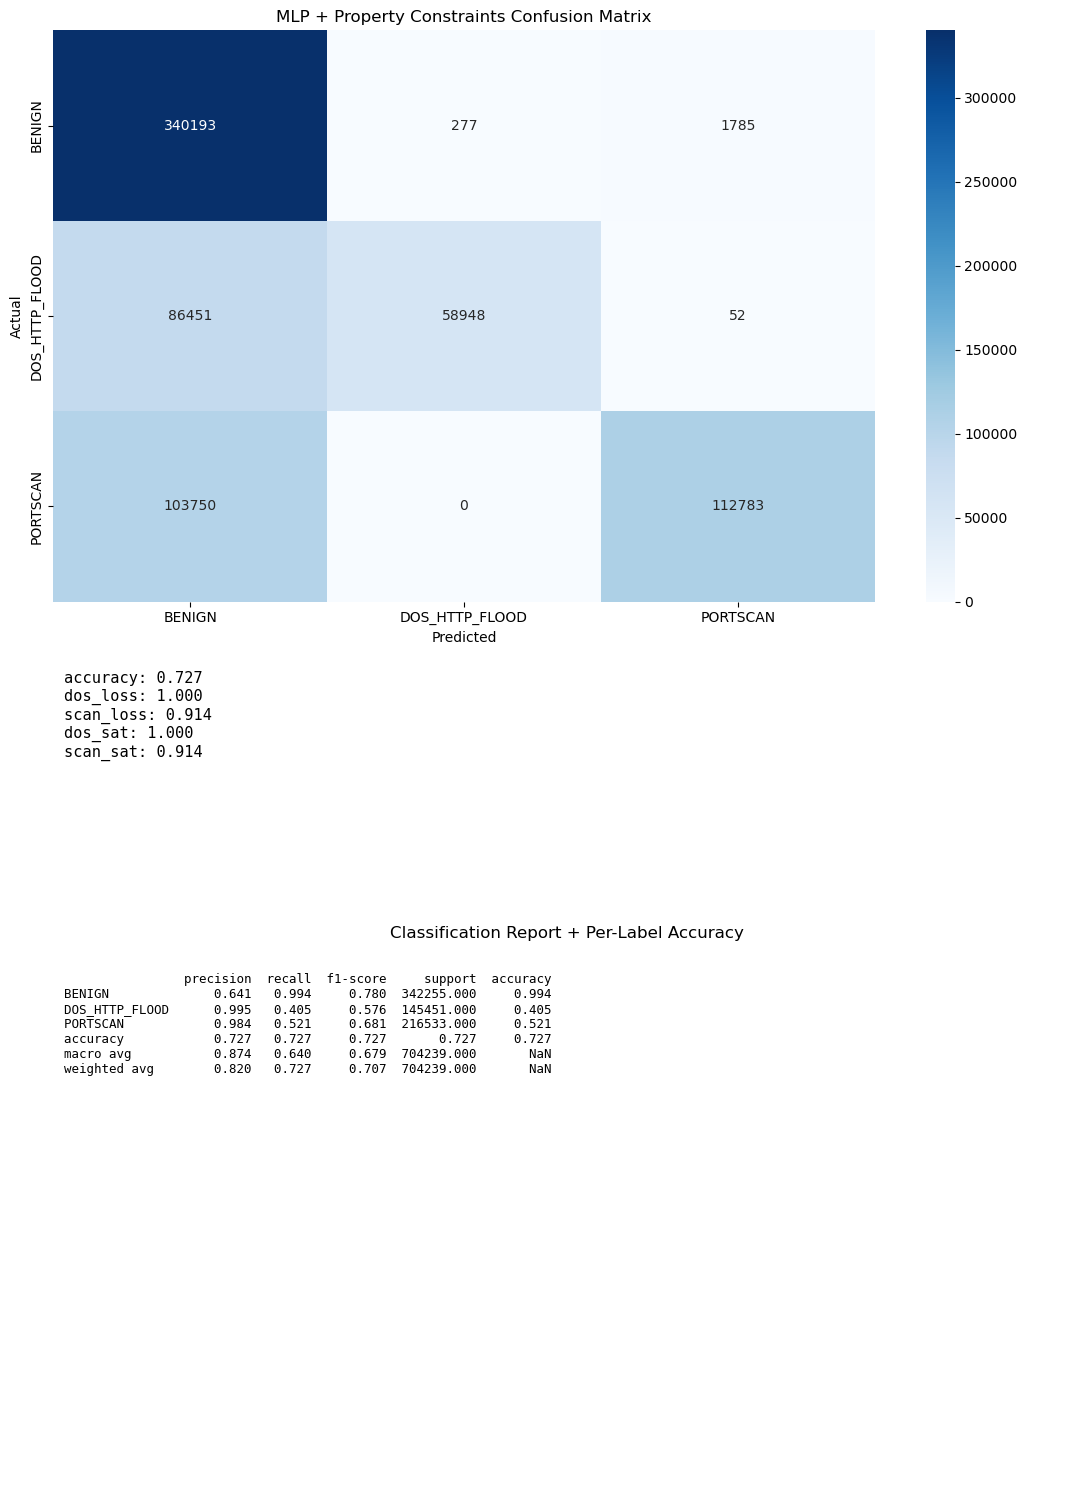

In [ ]:
plot_eval_summary(
    metrics,
    report_df,
    cm,
    labels,
    model_name="MLP + Property Constraints",
)